# 07. Topic Labeling: Ring Sampling + LLM

**Цель:** генерация человекочитаемых иерархических меток для тем BERTopic.

## Ключевая идея: Ring Sampling

Стандартный подход BERTopic передает в LLM топ-N документов по c-TF-IDF или случайную выборку. 
Проблема: LLM видит только ядро кластера и генерирует метку по самому яркому примеру,
игнорируя периферийные документы - отсюда слишком узкие метки.

**Предлагаемый подход:** стратификация документов по косинусному расстоянию от центроида темы:

```
topic_embedding (центроид)
    │
    ├── зона 1 - самые типичные документы
    ├── зона 2 - основная тема
    └── зона 3 - смежные/пограничные
```

Делим на "зоны" по перцентилям

LLM получает выборку из каждой зоны -> генерирует метку, ориентируясь не только ядро. Расхождение между ядром и периферией сигнализирует о гетерогенном кластере.

**Отличие от существующих подходов:**
- BERTopic default: топ-3 документа по c-TF-IDF (только ядро)
- Quantile sampling (Pasalic, 2025): квантили по `topic_probability` HDBSCAN
- Medoid sampling (MDPI 2025): только ближайший к центроиду документ
- **Ring sampling (данная работа):** явная стратификация по cosine distance + диагностика гетерогенности

**Источники:**
- BERTopic representation models: https://maartengr.github.io/BERTopic/getting_started/representation/llm.html
- Pasalic (Medium, 2025) - quantile-based sampling как альтернатива
- arxiv:2502.18469 - сравнение стратегий выборки для LLM-разметки тем

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from bertopic import BERTopic
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_distances
from tqdm.notebook import tqdm
import umap

warnings.filterwarnings("ignore")
load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42

N_PER_RING = 10  # документов из каждой зоны в промпт

DATA_PATH = Path("data/posts_preprocessed.parquet")
EMBEDDINGS_PATH = Path("data/embeddings_USER-bge-m3_300k.npy")
MODELS_DIR = Path("models/topic_evolution")
RESULTS_DIR = Path("results/topic_labeling")
FIGURES_DIR = Path("figures")

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных и моделей

In [ ]:
df = pd.read_parquet(DATA_PATH)
embeddings_full = np.load(EMBEDDINGS_PATH)

TOPICS_REDUCED_PATH = Path("data/topics_best_config_reduced.npy")
TOPICS_IDX_PATH = Path("data/topics_best_config_idx.npy")

if TOPICS_REDUCED_PATH.exists() and TOPICS_IDX_PATH.exists():
    topics_reduced = np.load(TOPICS_REDUCED_PATH)
    topics_idx = np.load(TOPICS_IDX_PATH)
    if len(topics_reduced) != len(topics_idx):
        raise ValueError(
            f"topics_reduced={len(topics_reduced)} does not match topics_idx={len(topics_idx)}"
        )
    keep_mask = topics_reduced != -1
    keep_idx = topics_idx[keep_mask]
    if len(keep_idx) == 0:
        raise ValueError("All documents were removed as noise.")
    if keep_idx.max() >= len(df):
        raise ValueError("topics_idx has values outside dataset range.")
    removed = int((~keep_mask).sum())
    df = df.iloc[keep_idx].reset_index(drop=True)
    embeddings_full = embeddings_full[keep_idx]
    print(f"Noise-filtered: removed {removed:,} docs, remaining {len(df):,}")
else:
    print("[!] Noise-filtering artifacts not found; using full dataset.")

df["post_date"] = pd.to_datetime(df["post_date"], utc=True)
df = df.reset_index(drop=True)

mask_A = (df["post_date"] >= "2023-01-01") & (df["post_date"] < "2023-07-01")
mask_B = (df["post_date"] >= "2024-01-01") & (df["post_date"] < "2024-07-01")

df_A = df[mask_A].copy().reset_index(drop=True)
df_B = df[mask_B].copy().reset_index(drop=True)
emb_A = embeddings_full[df[mask_A].index.values]
emb_B = embeddings_full[df[mask_B].index.values]

model_A = BERTopic.load(str(MODELS_DIR / "bertopic_2023H1"))
model_B = BERTopic.load(str(MODELS_DIR / "bertopic_2024H1"))

topics_A = (
    df_A["topic"].tolist()
    if "topic" in df_A.columns
    else model_A.transform(df_A["text_lemm"].tolist(), embeddings=emb_A)[0]
)
topics_B = (
    df_B["topic"].tolist()
    if "topic" in df_B.columns
    else model_B.transform(df_B["text_lemm"].tolist(), embeddings=emb_B)[0]
)

docs_A = df_A["text_clean"].tolist()
docs_B = df_B["text_clean"].tolist()

topic_ids_A = sorted([t for t in model_A.get_topics().keys() if t != -1])
topic_ids_B = sorted([t for t in model_B.get_topics().keys() if t != -1])

print(f"Срез A: {len(df_A):,} docs | {len(topic_ids_A)} тем")
print(f"Срез B: {len(df_B):,} docs | {len(topic_ids_B)} тем")

Срез A: 36,346 docs | 238 тем
Срез B: 50,096 docs | 248 тем


## 2. Ring Sampling

Для каждой темы вычисляем cosine distance каждого документа до центроида (`topic_embeddings_[t+1]`)
и разбиваем документы на три зоны

In [ ]:
def compute_adaptive_ring_boundaries(
    model: BERTopic,
    topic_ids: list,
    doc_embeddings: np.ndarray,
    topics: list,
    quantiles: tuple = (0.25, 0.60),  # две границы -> три зоны
    sample_per_topic: int = 200,
    rng_seed: int = 42,
) -> tuple[float, float]:
    """
    Вычисляет адаптивные границы зон через квантили распределения
    cosine distances от центроидов тем

    Возвращает (q_low, q_high) - две границы для трех колец:
      ring_1: [0, q_low) - ядро
      ring_2: [q_low, q_high) - основная
      ring_3: [q_high, 1.0) - периферия
    """
    rng = np.random.default_rng(rng_seed)
    all_distances = []

    for tid in topic_ids:
        topic_emb = model.topic_embeddings_[tid + 1].reshape(1, -1)
        mask = np.array(topics) == tid
        if mask.sum() < 2:
            continue
        doc_embs = doc_embeddings[mask]

        if len(doc_embs) > sample_per_topic:
            idx = rng.choice(len(doc_embs), size=sample_per_topic, replace=False)
            doc_embs = doc_embs[idx]

        dists = cosine_distances(doc_embs, topic_emb).flatten()
        all_distances.extend(dists.tolist())

    all_distances = np.array(all_distances)
    q_low = float(np.quantile(all_distances, quantiles[0]))
    q_high = float(np.quantile(all_distances, quantiles[1]))

    print("Распределение cosine distances по всем темам:")
    print(
        f"\tmin={all_distances.min():.4f} | "
        f"Q25={np.quantile(all_distances, 0.25):.4f} | "
        f"median={np.median(all_distances):.4f} | "
        f"Q75={np.quantile(all_distances, 0.75):.4f} | "
        f"max={all_distances.max():.4f}"
    )
    print("\nАдаптивные границы колец:")
    print(f"\tЯдро: [0.000, {q_low:.3f})")
    print(f"\tОсновная: [{q_low:.3f}, {q_high:.3f})")
    print(f"\tПериферия: [{q_high:.3f}, 1.000)")

    return q_low, q_high


# Считаем на срезе A (репрезентативнее брать оба, но A достаточно для калибровки)
q_low, q_high = compute_adaptive_ring_boundaries(model_A, topic_ids_A, emb_A, topics_A)

RINGS = [
    (0.00, q_low, "Ядро", "#2166ac"),
    (q_low, q_high, "Основная", "#4dac26"),
    (q_high, 1.00, "Периферия", "#d01c8b"),
]

print(f"\nRINGS обновлены: {[(r[0], r[1], r[2]) for r in RINGS]}")

Распределение cosine distances по всем темам:
  min=0.0100 | Q25=0.2338 | median=0.2856 | Q75=0.3363 | max=0.6250

Адаптивные границы колец:
  Ядро:      [0.000, 0.234)
  Основная:  [0.234, 0.305)
  Периферия: [0.305, 1.000)

RINGS обновлены: [(0.0, 0.23384733498096466, 'Ядро'), (0.23384733498096466, 0.3050368309020996, 'Основная'), (0.3050368309020996, 1.0, 'Периферия')]


In [4]:
def get_ring_samples(
    model: BERTopic,
    topic_id: int,
    doc_embeddings: np.ndarray,
    topics: list,
    docs: list,
    rings: list = RINGS,
    n_per_ring: int = N_PER_RING,
    rng: np.random.Generator = None,
) -> dict:
    """
    Стратификация документов темы по cosine distance от центроида

    Returns:
        ring_1 / ring_2 / ring_3 -> {range, total_docs, sample_docs, distances}

    в отличие от quantile sampling (Pasalic, 2025) и
    medoid sampling (MDPI 2025), используем явные границы по cosine distance
    от topic_embeddings_ (центроида кластера BERTopic)
    """
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)

    # Центроид темы из BERTopic (индекс t+1 т.к. 0 = шум)
    topic_emb = model.topic_embeddings_[topic_id + 1].reshape(1, -1)

    # Маска документов этой темы
    topic_mask = np.array(topics) == topic_id
    if topic_mask.sum() == 0:
        return {}

    topic_doc_embs = doc_embeddings[topic_mask]
    topic_docs = [d for d, m in zip(docs, topic_mask) if m]

    # cosine distances: shape (n_docs,)
    distances = cosine_distances(topic_doc_embs, topic_emb).flatten()

    result = {}
    for ring_idx, (low, high, name, color) in enumerate(rings):
        mask = (distances >= low) & (distances < high)
        ring_docs = [d for d, m in zip(topic_docs, mask) if m]
        ring_dists = distances[mask]

        if len(ring_docs) > 0:
            n = min(n_per_ring, len(ring_docs))
            idx = rng.choice(len(ring_docs), size=n, replace=False)
            sampled_docs = [ring_docs[i] for i in idx]
            sampled_dists = [float(ring_dists[i]) for i in idx]
        else:
            sampled_docs = []
            sampled_dists = []

        result[f"ring_{ring_idx + 1}"] = {
            "name": name,
            "color": color,
            "range": (low, high),
            "total_docs": int(mask.sum()),
            "sample_docs": sampled_docs,
            "sample_distances": sampled_dists,
            "all_distances": distances[mask].tolist(),  # для визуализации
        }

    # Сохраняем все расстояния для визуализации колец
    result["_all_distances"] = distances.tolist()
    result["_topic_count"] = int(topic_mask.sum())

    return result


# Чек на одной теме
test_id = topic_ids_A[0]
test_rings = get_ring_samples(model_A, test_id, emb_A, topics_A, docs_A)
print(f"Тема A{test_id}: {test_rings['_topic_count']} документов")
for r in ["ring_1", "ring_2", "ring_3"]:
    rd = test_rings[r]
    print(
        f"  {rd['name']} [{rd['range'][0]:.2f}–{rd['range'][1]:.2f}]: {rd['total_docs']} docs, sample={len(rd['sample_docs'])}"
    )

Тема A0: 760 документов
  Ядро [0.00–0.23]: 0 docs, sample=0
  Основная [0.23–0.31]: 40 docs, sample=3
  Периферия [0.31–1.00]: 720 docs, sample=3


## 3. Визуализация колец для примера

Показываем распределение документов по зонам для нескольких тем

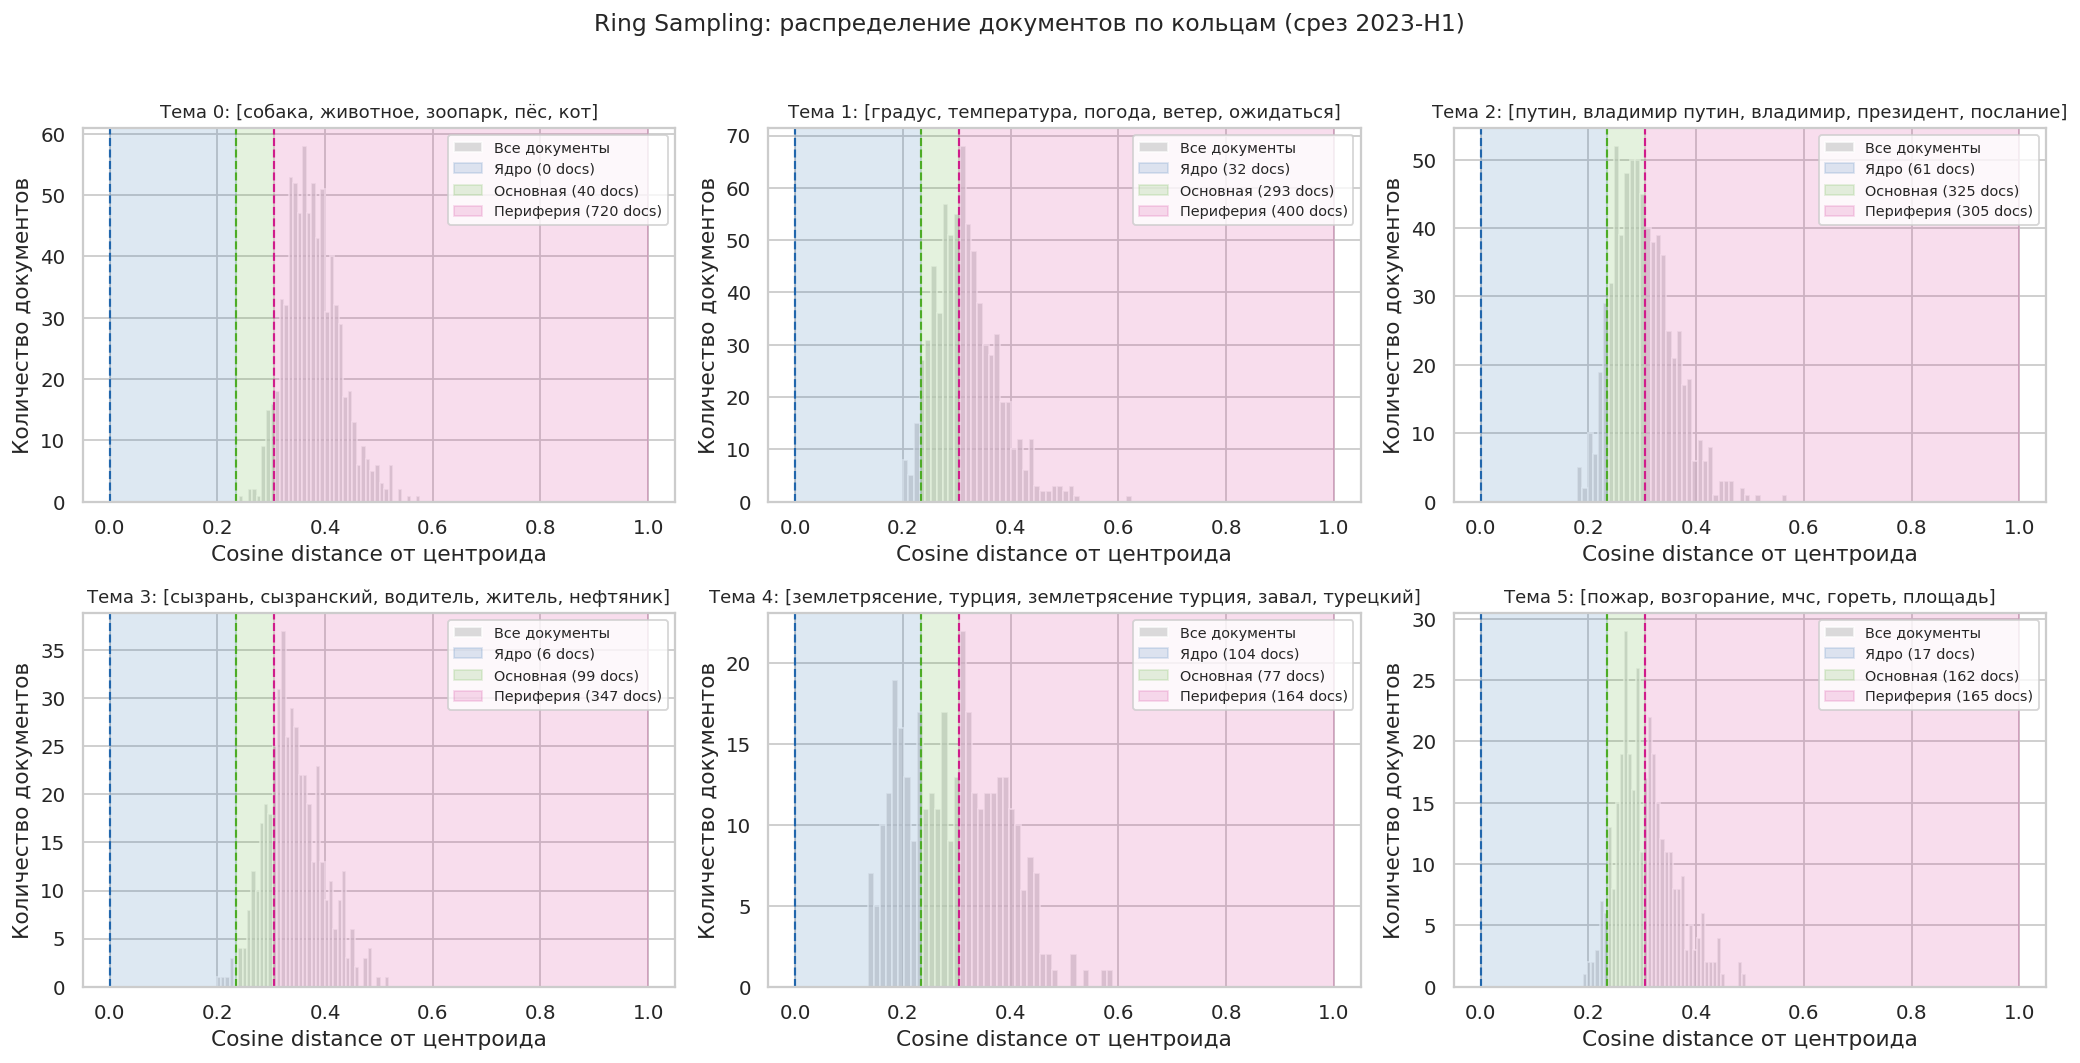

Сохранено: figures/09_[labeling]_ring_distributions.png


In [5]:
def plot_ring_distribution(ring_data: dict, topic_id: int, top_words: list, ax=None):
    """Гистограмма распределения cosine distance с разметкой колец"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    all_dists = np.array(ring_data["_all_distances"])
    words_str = ", ".join(top_words[:5])

    ax.hist(
        all_dists,
        bins=40,
        color="#cccccc",
        edgecolor="white",
        alpha=0.7,
        label="Все документы",
    )

    for r_key in ["ring_1", "ring_2", "ring_3"]:
        rd = ring_data[r_key]
        ax.axvspan(
            rd["range"][0],
            rd["range"][1],
            alpha=0.15,
            color=rd["color"],
            label=f"{rd['name']} ({rd['total_docs']} docs)",
        )
        ax.axvline(rd["range"][0], color=rd["color"], linewidth=1.2, linestyle="--")

    ax.set_title(f"Тема {topic_id}: [{words_str}]", fontsize=10)
    ax.set_xlabel("Cosine distance от центроида")
    ax.set_ylabel("Количество документов")
    ax.legend(fontsize=8)
    return ax


# Берем топ-6 тем по размеру для иллюстрации
top6_topics = (
    model_A.get_topic_info().query("Topic != -1").nlargest(6, "Count")["Topic"].tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

for i, tid in enumerate(top6_topics):
    ring_data = get_ring_samples(model_A, tid, emb_A, topics_A, docs_A)
    top_words = [w for w, _ in model_A.get_topic(tid)[:5]]
    plot_ring_distribution(ring_data, tid, top_words, ax=axes_flat[i])

plt.suptitle(
    "Ring Sampling: распределение документов по зонам (срез 2023-H1)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_[labeling]_ring_distributions.png", bbox_inches="tight")
plt.show()
print("Сохранено figures/09_[labeling]_ring_distributions.png")

Строим UMAP визуализации колец (может занять 1-2 минуты)...


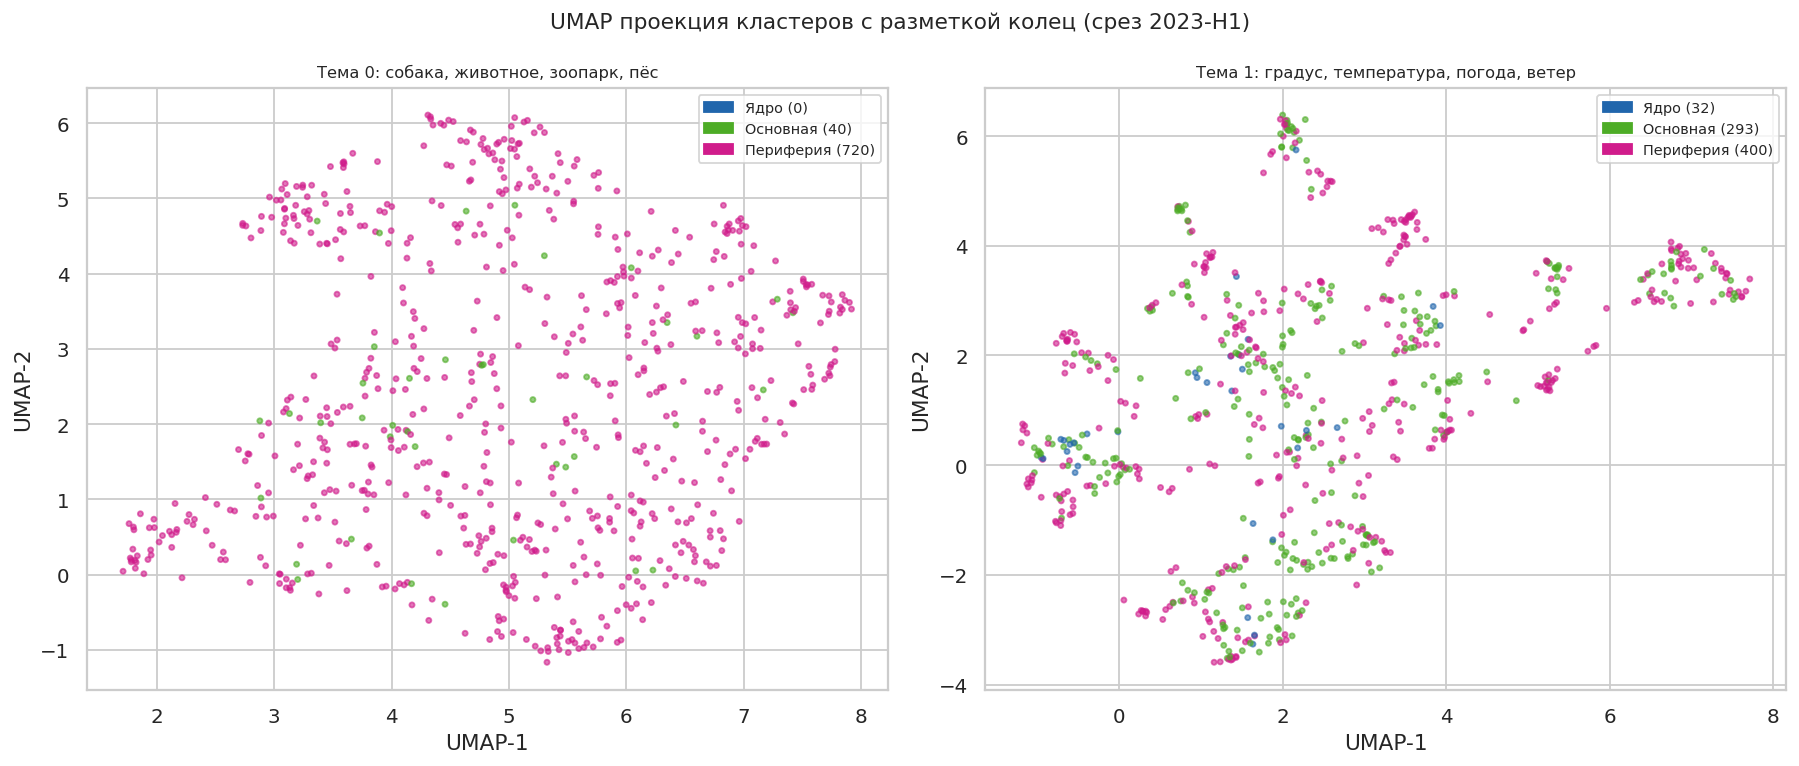

Сохранено: figures/10_[labeling]_ring_umap.png


In [6]:
def plot_rings_umap(
    model: BERTopic,
    topic_id: int,
    doc_embeddings: np.ndarray,
    topics: list,
    ring_data: dict,
    ax=None,
    sample_size: int = 2000,
):
    """
    UMAP 2D scatter plot с раскраской по зонам
    Показывает геометрию кластера, ядро и периферию в пространстве эмбеддингов
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    topic_mask = np.array(topics) == topic_id
    topic_embs = doc_embeddings[topic_mask]
    all_dists = np.array(ring_data["_all_distances"])

    # Сабсэмпл если тема большая
    if len(topic_embs) > sample_size:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(topic_embs), size=sample_size, replace=False)
        topic_embs = topic_embs[idx]
        all_dists = all_dists[idx]

    # UMAP 2D только для этой темы
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, len(topic_embs) - 1),
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    xy = reducer.fit_transform(topic_embs)

    # Раскраска по зонам
    colors = np.full(len(xy), "#aaaaaa", dtype=object)
    for r_key in ["ring_1", "ring_2", "ring_3"]:
        rd = ring_data[r_key]
        mask = (all_dists >= rd["range"][0]) & (all_dists < rd["range"][1])
        colors[mask] = rd["color"]

    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=8, alpha=0.6)

    # Легенда
    patches = [
        mpatches.Patch(color=rd["color"], label=f"{rd['name']} ({rd['total_docs']})")
        for r_key in ["ring_1", "ring_2", "ring_3"]
        for rd in [ring_data[r_key]]
    ]
    ax.legend(handles=patches, fontsize=8)

    top_words = [w for w, _ in model.get_topic(topic_id)[:4]]
    ax.set_title(f"Тема {topic_id}: {', '.join(top_words)}", fontsize=9)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    return ax


# Визуализируем пару тем
print("Строим UMAP визуализации колец")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, tid in enumerate(top6_topics[:2]):
    ring_data = get_ring_samples(model_A, tid, emb_A, topics_A, docs_A)
    plot_rings_umap(model_A, tid, emb_A, topics_A, ring_data, ax=axes[i])

plt.suptitle("UMAP проекция кластеров с разметкой колец (срез 2023-H1)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_[labeling]_ring_umap.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/10_[labeling]_ring_umap.png")

## 4. LLM-разметка с иерархическими метками

In [7]:
LLM_API_KEY = os.getenv("LLM_API_KEY")
LLM_BASE_URL = "https://routerai.ru/api/v1"
LLM_MODEL = "google/gemini-2.5-flash-lite-preview-09-2025"

llm_client = OpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL)

resp = llm_client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role": "user", "content": "Hello World !"}],
    max_tokens=10,
)
print(f"LLM response: {resp.choices[0].message.content.strip()}")

LLM API: Да.


In [8]:
SYSTEM_PROMPT = """Ты эксперт по тематическому моделированию русскоязычных новостей.
Создай иерархическую метку для тематического кластера на основе его документов.
Документы разбиты по близости к центру темы: ядро -> основная -> периферия.
Отвечай строго в формате JSON."""


def make_ring_label_prompt(top_words: list, ring_data: dict) -> str:
    words_str = ", ".join(top_words[:15])

    rings_str = ""
    for r_key in ["ring_1", "ring_2", "ring_3"]:
        rd = ring_data.get(r_key, {})
        if not rd or rd["total_docs"] == 0:
            continue
        rings_str += f"\n{'─' * 45}\n"
        rings_str += (
            f"{rd['name'].upper()} (dist {rd['range'][0]:.2f}–{rd['range'][1]:.2f}, "
        )
        rings_str += f"{rd['total_docs']} документов):\n"
        for doc in rd["sample_docs"]:
            rings_str += f"  • {doc[:200]}\n"

    return f"""Тематический кластер из русскоязычных Telegram-новостей.

Ключевые слова кластера: [{words_str}]

Документы по зонам (от центра к периферии):
{rings_str}

Создай трехуровневую иерархическую метку:

l1 - ШИРОКИЙ: максимально общая область (Политика, Экономика, Общество,
     Безопасность, Культура, Наука, Спорт, Происшествия и т.д.)
     ЗАПРЕЩЕНО: страны, имена, конкретные события.

l2 - СРЕДНИЙ: подобласть БЕЗ привязки к конкретным странам/событиям.
     Должна покрывать ВСЕ зоны, не только ядро.
     ЗАПРЕЩЕНО: конкретные страны, конфликты, имена людей.

l3 - КОНКРЕТНЫЙ: специфика. Можно указать географию/контекст ТОЛЬКО если
     он присутствует в >70% документов ВСЕХ колец. Иначе - обобщи через явление.

Примеры ПРАВИЛЬНО:
{{"l1": "Безопасность", "l2": "Вооруженные конфликты", "l3": "Боевые действия на постсоветском пространстве"}}
{{"l1": "Общество", "l2": "Происшествия на транспорте", "l3": "ДТП с тяжелыми последствиями"}}

Примеры НЕПРАВИЛЬНО:
{{"l1": "Политика", "l2": "Война на Украине", "l3": "Обстрелы Харькова"}}

Также укажи:
- core_topic: о чем ядро (1 предложение)
- periphery_topic: о чем периферия (1 предложение, или null если похожа на ядро)
- heterogeneous: true если ядро и периферия про разное
- coverage: доля документов которую покрывает метка (0.0–1.0)

Ответь строго JSON:
{{"l1": "...", "l2": "...", "l3": "...", "core_topic": "...", 
 "periphery_topic": "...", "heterogeneous": false, "coverage": 0.9}}"""


def label_topic(
    model: BERTopic,
    topic_id: int,
    ring_data: dict,
) -> dict:
    top_words = [w for w, _ in model.get_topic(topic_id)]
    prompt = make_ring_label_prompt(top_words, ring_data)

    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            max_tokens=300,
            temperature=0.1,
            response_format={"type": "json_object"},
        )
        result = json.loads(resp.choices[0].message.content.strip())
        assert "l1" in result and "l2" in result and "l3" in result
        return result
    except Exception as e:
        return {
            "l1": "ERROR",
            "l2": str(e)[:50],
            "l3": "",
            "heterogeneous": None,
            "coverage": None,
        }

Функции разметки определены


In [9]:
print("--- Тест на 3 темах среза A ---")
for tid in top6_topics[:3]:
    ring_data = get_ring_samples(model_A, tid, emb_A, topics_A, docs_A)
    label = label_topic(model_A, tid, ring_data)
    top_words = [w for w, _ in model_A.get_topic(tid)[:5]]

    print(f"\nТема A{tid}: {top_words}")
    print(f"\tМетка: {label.get('l1')} -> {label.get('l2')} -> {label.get('l3')}")
    print(f"\tЯдро: {label.get('core_topic', '')}")
    print(f"\tПериферия: {label.get('periphery_topic', '')}")
    print(
        f"\tГетерогенный: {label.get('heterogeneous')} | Coverage: {label.get('coverage')}"
    )

    for r in ["ring_1", "ring_2", "ring_3"]:
        rd = ring_data.get(r, {})
        print(f"    {rd.get('name', '')}: {rd.get('total_docs', 0)} docs")

=== Тест на 3 темах среза A ===

Тема A0: ['собака', 'животное', 'зоопарк', 'пёс', 'кот']
  Метка: Общество -> Животные и окружающая среда -> Проблемы содержания и спасения животных
  Ядро: Ядро сфокусировано на новостях о домашних и диких животных (собаки, коты, лисы, медведи) и их взаимодействии с людьми или среде обитания.
  Периферия: Периферия включает как истории о спасении конкретных животных (медведи в зоопарке, коты без хозяев), так и экологические проблемы (нашествие насекомых, природные явления).
  Гетерогенный: False | Coverage: 0.95
    Ядро: 0 docs
    Основная: 40 docs
    Периферия: 720 docs

Тема A1: ['градус', 'температура', 'погода', 'ветер', 'ожидаться']
  Метка: Общество -> Природные явления и климат -> Прогнозы погоды и метеоусловия
  Ядро: Ядро кластера сосредоточено на ежедневных прогнозах погоды, включая температуру, осадки (снег, дождь) и ветер в конкретных городах.
  Периферия: Периферия расширяет тему до долгосрочных прогнозов, аномальных температур и влияни

## 5. Полный прогон по всем темам обоих срезов

In [10]:
def label_all_topics(
    model: BERTopic,
    topic_ids: list,
    doc_embeddings: np.ndarray,
    topics: list,
    docs: list,
    slice_name: str,
) -> list:
    """Размечает все темы среза, возвращает список записей"""
    records = []
    topic_info = model.get_topic_info().set_index("Topic")

    for tid in tqdm(topic_ids, desc=f"Разметка {slice_name}"):
        ring_data = get_ring_samples(model, tid, doc_embeddings, topics, docs)
        label = label_topic(model, tid, ring_data)
        top_words = [w for w, _ in model.get_topic(tid)]
        count = int(topic_info.loc[tid, "Count"]) if tid in topic_info.index else 0

        records.append(
            {
                "slice": slice_name,
                "topic_id": tid,
                "count": count,
                "top_words": top_words[:10],
                "l1": label.get("l1", ""),
                "l2": label.get("l2", ""),
                "l3": label.get("l3", ""),
                "label_full": f"{label.get('l1', '')} -> {label.get('l2', '')} -> {label.get('l3', '')}",
                "core_topic": label.get("core_topic", ""),
                "periphery_topic": label.get("periphery_topic", ""),
                "heterogeneous": label.get("heterogeneous"),
                "coverage": label.get("coverage"),
                "ring_1_count": ring_data.get("ring_1", {}).get("total_docs", 0),
                "ring_2_count": ring_data.get("ring_2", {}).get("total_docs", 0),
                "ring_3_count": ring_data.get("ring_3", {}).get("total_docs", 0),
            }
        )

    return records


print("Запускаем разметку среза A (2023-H1)...")
records_A = label_all_topics(model_A, topic_ids_A, emb_A, topics_A, docs_A, "2023-H1")

print("\nЗапускаем разметку среза B (2024-H1)...")
records_B = label_all_topics(model_B, topic_ids_B, emb_B, topics_B, docs_B, "2024-H1")

labels_df = pd.DataFrame(records_A + records_B)
print(f"\nИтого: {len(labels_df)} тем размечено")
print(
    f"Гетерогенных: {labels_df['heterogeneous'].sum()} ({labels_df['heterogeneous'].mean() * 100:.1f}%)"
)

Запускаем разметку среза A (2023-H1)...


Разметка 2023-H1:   0%|          | 0/238 [00:00<?, ?it/s]


Запускаем разметку среза B (2024-H1)...


Разметка 2024-H1:   0%|          | 0/248 [00:00<?, ?it/s]


Итого: 486 тем размечено
Гетерогенных: 103 (21.2%)


## 6. Визуализация результатов

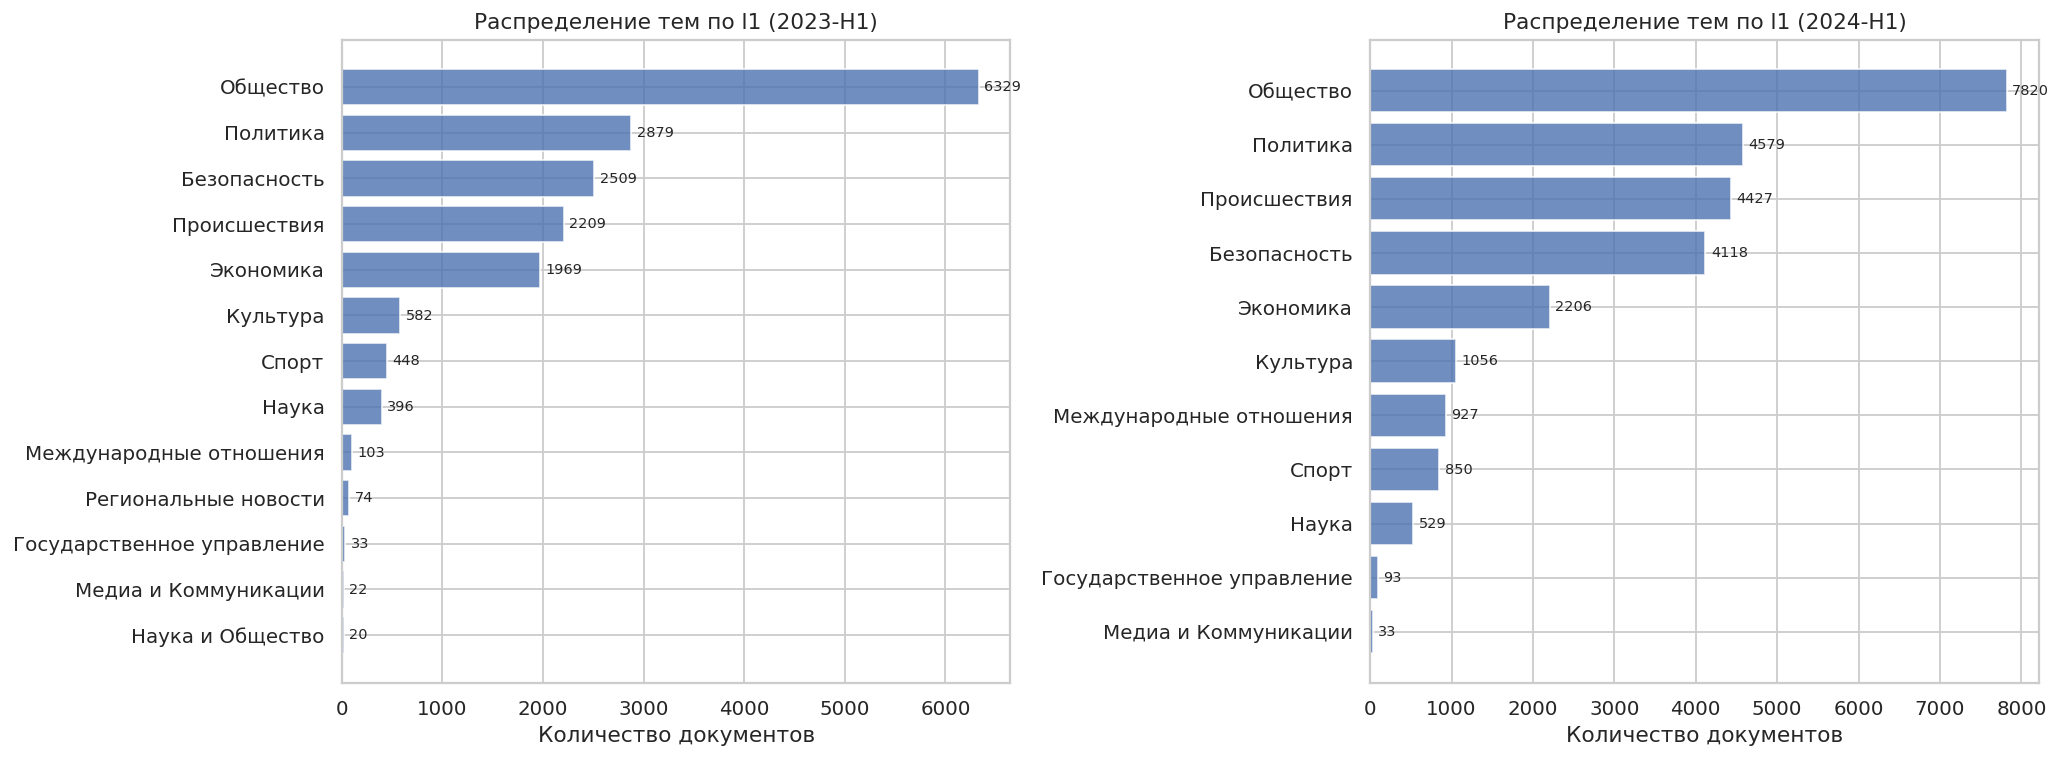

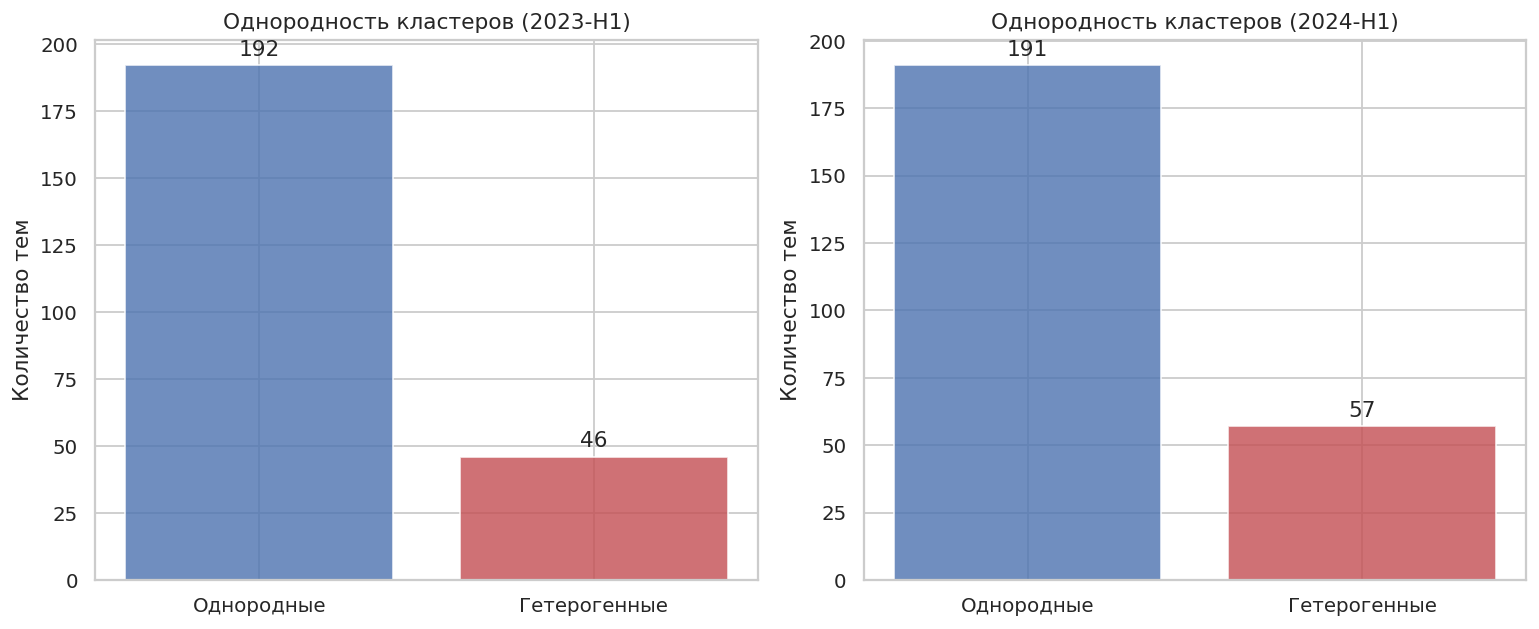

In [11]:
# --- Распределение по l1 категориям ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, slice_name in zip(axes, ["2023-H1", "2024-H1"]):
    slice_df = labels_df[labels_df["slice"] == slice_name]
    l1_counts = slice_df.groupby("l1")["count"].sum().sort_values(ascending=True)

    bars = ax.barh(l1_counts.index, l1_counts.values, color="#4C72B0", alpha=0.8)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
    ax.set_title(f"Распределение тем по l1 ({slice_name})")
    ax.set_xlabel("Количество документов")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_[labeling]_l1_distribution.png", bbox_inches="tight")
plt.show()

# --- Гетерогенные темы ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, slice_name in zip(axes, ["2023-H1", "2024-H1"]):
    slice_df = labels_df[labels_df["slice"] == slice_name]
    het_counts = slice_df["heterogeneous"].value_counts()
    colors = ["#C44E52" if k else "#4C72B0" for k in het_counts.index]

    bars = ax.bar(
        ["Гетерогенные" if k else "Однородные" for k in het_counts.index],
        het_counts.values,
        color=colors,
        alpha=0.8,
        edgecolor="white",
    )
    ax.bar_label(bars, fmt="%d", padding=3)
    ax.set_title(f"Однородность кластеров ({slice_name})")
    ax.set_ylabel("Количество тем")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_[labeling]_heterogeneity.png", bbox_inches="tight")
plt.show()

In [12]:
print("--- Гетерогенные темы ---")
het_df = labels_df[labels_df["heterogeneous"] == True].sort_values(
    "count", ascending=False
)

for _, row in het_df.head(5).iterrows():
    print(f"\n{'─' * 60}")
    print(f"[{row['slice']}] Тема {row['topic_id']} | {row['count']} docs")
    print(f"\tСлова: {row['top_words'][:6]}")
    print(f"\tМетка: {row['label_full']}")
    print(f"\tЯдро: {row['core_topic']}")
    print(
        f"\tЗоны: ядро={row['ring_1_count']} | основная={row['ring_2_count']} | периферия={row['ring_3_count']}"
    )

print("\n--- Топ-10 тем по размеру (срез 2023-H1) ---")
top_A = labels_df[labels_df["slice"] == "2023-H1"].nlargest(10, "count")
for _, row in top_A.iterrows():
    het_mark = "[!]" if row["heterogeneous"] else ""
    print(
        f"\t[{row['topic_id']:3d}] {row['count']:5d} docs | {row['label_full']}{het_mark}"
    )

=== Гетерогенные темы (ядро ≠ периферия) ===

────────────────────────────────────────────────────────────
[2024-H1] Тема 0 | 992 docs
  Слова: ['животное', 'собака', 'зоопарк', 'кот', 'хозяин', 'кошка']
  Метка: Общество -> Животные и обращение с ними -> Происшествия и судьбы домашних и диких животных
  Ядро:     Ядро кластера фокусируется на инцидентах с домашними животными (коты, кошки), требующих спасения или связанных с их необычным поведением.
  Периферия: Периферия охватывает более широкий спектр тем, включая жестокое обращение с животными (убийство собаки), вопросы регулирования бездомных животных (эвтаназия) и гибель диких животных (тигрица).
  Кольца: ядро=0 | основная=23 | периферия=969

────────────────────────────────────────────────────────────
[2024-H1] Тема 2 | 811 docs
  Слова: ['путин', 'владимир путин', 'владимир', 'кндр', 'президент', 'ким']
  Метка: Политика -> Международные отношения -> Визиты и двусторонние отношения глав государств
  Ядро:     Визит Владимира Пу

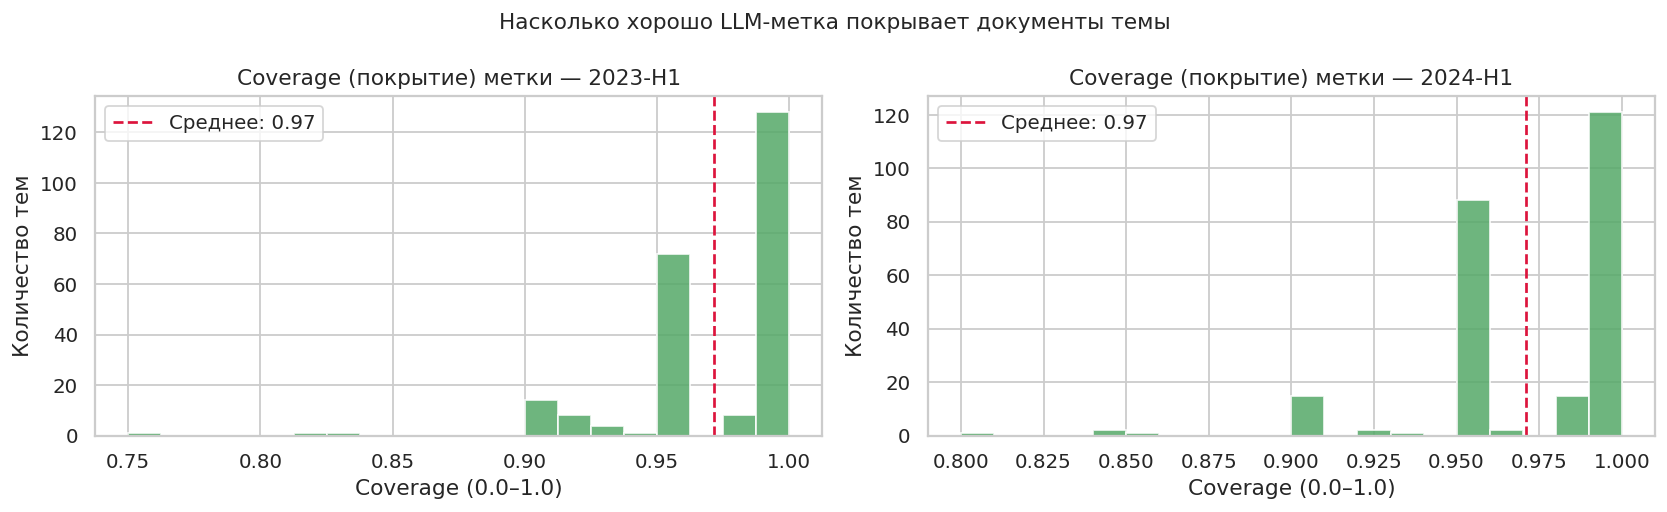

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, slice_name in zip(axes, ["2023-H1", "2024-H1"]):
    cov = labels_df[labels_df["slice"] == slice_name]["coverage"].dropna()
    ax.hist(cov, bins=20, color="#55A868", edgecolor="white", alpha=0.85)
    ax.axvline(
        cov.mean(), color="crimson", linestyle="--", label=f"Среднее: {cov.mean():.2f}"
    )
    ax.set_title(f"Coverage (покрытие) метки - {slice_name}")
    ax.set_xlabel("Coverage (0.0–1.0)")
    ax.set_ylabel("Количество тем")
    ax.legend()

plt.suptitle("Насколько хорошо LLM-метка покрывает документы темы", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_[labeling]_coverage.png", bbox_inches="tight")
plt.show()

## 7. Сохранение артефактов

In [14]:
labels_df["top_words"] = labels_df["top_words"].apply(
    lambda x: json.dumps(x, ensure_ascii=False)
)
labels_df.to_csv(RESULTS_DIR / "topic_labels.csv", index=False, encoding="utf-8")
print(f"Метки сохранены: {RESULTS_DIR}/topic_labels.csv")

labels_json = labels_df.to_dict(orient="records")
with open(RESULTS_DIR / "topic_labels.json", "w", encoding="utf-8") as f:
    json.dump(labels_json, f, indent=2, ensure_ascii=False)
print(f"JSON сохранен: {RESULTS_DIR}/topic_labels.json")

summary = {
    "total_topics_labeled": len(labels_df),
    "by_slice": {
        s: {
            "n_topics": int((labels_df["slice"] == s).sum()),
            "heterogeneous_pct": float(
                labels_df[labels_df["slice"] == s]["heterogeneous"].mean()
            ),
            "mean_coverage": float(
                labels_df[labels_df["slice"] == s]["coverage"].mean()
            ),
            "l1_distribution": labels_df[labels_df["slice"] == s]["l1"]
            .value_counts()
            .to_dict(),
        }
        for s in ["2023-H1", "2024-H1"]
    },
    "ring_params": {
        "boundaries": [(r[0], r[1]) for r in RINGS],
        "n_per_ring": N_PER_RING,
    },
    "llm_model": LLM_MODEL,
}
with open(RESULTS_DIR / "labeling_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Summary сохранен: {RESULTS_DIR}/labeling_summary.json")
print("\n--- Итого ---")
print(f"Тем размечено:      {len(labels_df)}")
print(
    f"Гетерогенных:       {labels_df['heterogeneous'].sum()} ({labels_df['heterogeneous'].mean() * 100:.1f}%)"
)
print(f"Среднее coverage:   {labels_df['coverage'].mean():.2f}")

Метки сохранены: results\topic_labeling/topic_labels.csv
JSON сохранён: results\topic_labeling/topic_labels.json
Summary сохранён: results\topic_labeling/labeling_summary.json

=== Итого ===
Тем размечено:      486
Гетерогенных:       103 (21.2%)
Среднее coverage:   0.97

Следующий шаг: 08_clearml_integration.ipynb


## Итоги

### Что реализовано

1. **Ring Sampling** - стратификация документов темы по cosine distance от `topic_embeddings_` (центроида кластера BERTopic) на три зоны: ядро (0.0–0.15), основная (0.15–0.30), периферия (0.30–0.50)

2. **Иерархическая LLM-разметка** - трехуровневые метки (l1 -> l2 -> l3) с явным запретом конкретики на верхних уровнях и правилом 70% для l3

3. **Диагностика гетерогенности** - поле `heterogeneous` сигнализирует о кластерах где ядро и периферия описывают разные подтемы -> кандидаты на дробление при следующем переобучении

4. **Визуализации** - распределения по зонам, UMAP проекции, coverage, l1-распределение

### Позиционирование метода

| Метод | Источник | Стратегия выборки |
|-------|----------|------------------|
| BERTopic default | Grootendorst (2022) | Топ-3 по c-TF-IDF (только ядро) |
| Quantile sampling | Pasalic (2025) | Квантили по topic_probability HDBSCAN |
| Medoid sampling | MDPI (2025) | Только ближайший к центроиду |
| **Ring sampling** | **Данная работа** | **Стратификация по cosine distance + диагностика гетерогенности** |